Rod Ciombor <br>
3/2/26<br>
CIS-2532-NET01<br>
Dr. Sheikh Shamsuddin<br>
Week 5 Lab

<b>Functions library contents</b><br>
Here is a list of the contents in <b>week5hw.py</b>
<br><br>

In [ ]:
# Author:       Rod Ciombor
# Date:         03/02/2026
# Instructor:   Dr. Sheikh Shamsuddin
# Class:        CIS-2532-NET01

import time
import random
import matplotlib.pyplot as plt

RANGE_SIZES = [10000, 30000, 50000, 70000, 90000]
RANDOM_NUM_RANGE = 10000
ALGO_NAMES = ['Bubble Sort', 'Shell Sort', 'Quick Sort']

def bubbleSort(data):
    '''
    Name:
    bubbleSort()

    Parameters:
    data (list): List of randomly generated numbers to be sorted
        
    Returns:
    Nothing, can be modified to return sorted list

    Descr:
    This function takes an unsorted list of values 
    and sorts it using the Bubble Sort algorithm
    '''
    count = 0
    for i in range(len(data)):
        swapped = False
        for j in range(len(data) - 1):
            count += 1
            if data[j + 1] < data[j]:
                data[j + 1], data[j] = data[j], data[j + 1]
                swapped = True
        if not swapped:
            break        

def shellSort(data):
    '''
    Name:
    shellSort()

    Parameters:
    data (list): List of randomly generated numbers to be sorted
        
    Returns:
    Nothing, can be modified to return sorted list

    Descr:
    This function takes an unsorted list of values 
    and sorts it using the Shell Sort algorithm
    '''
    start = 0
    while start < len(data):
        minIndex = start
        minValue = data[start]
        for i in range(start, len(data)):
            if data[i] < minValue:
                minIndex = i
            minValue = data[i]
        if minIndex != start:
            data[start], data[minIndex] = data[minIndex], data[start]    
        start += 1

def quickSort(data):
    '''
    Name:
    quickSort()

    Parameters:
    data (list): List of randomly generated numbers to be sorted
        
    Returns:
    Nothing, can be modified to return sorted list

    Descr:
    This function takes an unsorted list of values 
    and sorts it using the Quick Sort algorithm.
    
    It abstracts the logic away from the user and sorts the data
    by calling quickSort2()
    '''
    quickSort2(data, 0, len(data) - 1)
    
    #Optional if you want to return sorted data
    #data = quickSort2(data, 0, len(data) - 1)
    #return data

def quickSort2(data, low, hi):
    '''
    Name:
    quickSort2()

    Parameters:
    data (list): The list of comparable elements to be sorted.
    low (int): The starting index of the sublist/partition.
    hi (int): The ending index of the sublist/partition.
            
    Returns:
    None

    Descr:
    The purpose of this function is to recursively sort a list
    using the Quick Sort algorithm.

    This function checks whether the current partition contains
    more than one element. If so, it calls getPartition() to
    determine the correct position of the pivot element.

    It then recursively applies Quick Sort to the left and right
    sub-partitions on either side of the pivot until the entire
    list is sorted in place.
    '''
    if low < hi:
        p = getPartition(data, low, hi)
        quickSort2(data, low, p - 1)
        quickSort2(data, p + 1, hi)

        #Optional if you want to return sorted data
        #data = quickSort2(data, low, p - 1)
        #data = quickSort2(data, p + 1, hi)
        #return data

def getPartition(data, low, hi):
    '''
    Name:
    getPartition()

    Parameters:
    data (list): The list of comparable elements.
    low (int): The starting index of the sublist/partition.
    hi (int): The ending index of the sublist/partition.
            
    Returns:
    int: The final index position of the pivot element.

    Descr:
    The purpose of this function is to partition a sublist
    of 'data' for use in the Quick Sort algorithm.

    This function selects a pivot using getPivot(), moves the
    pivot value to the beginning of the partition, and then
    rearranges the elements so that all values less than the
    pivot are placed to its left and all greater values remain
    to its right.

    After partitioning is complete, the pivot is moved to its
    correct sorted position, and the index of that position
    is returned.
    '''
    pivotIndex = getPivot(data, low, hi)
    pivotValue = data[pivotIndex]
    data[pivotIndex], data[low] = data[low], data[pivotIndex]
    border = low

    for i in range(low, hi + 1):
        if data[i] < pivotValue:
            border += 1
            data[i], data[border] = data[border], data[i]
    data[low], data[border] = data[border], data[low]      
    
    return border   

def getPivot(data, low, hi):
    '''
    Name:
    getPivot()

    Parameters:
    data (list): The list of comparable elements.
    low (int): The starting index of the sublist/partition.
    hi (int): The ending index of the sublist/partition.
        
    Returns:
    int: The index of the chosen pivot element.

    Descr:
    The purpose of this function is to determine and 
    return a pivot index for use in Quick Sort.

    This function selects a pivot index from the sublist of 'data'
    bounded by the indices 'low' and 'hi'. It uses a median-of-three
    strategy, comparing the values at the low, middle, and high
    indices to choose a more balanced pivot.
    '''
    mid = (hi + low) // 2
    pivot = hi
    if data[low] < data[mid]:
        if data[mid] < data[hi]:
            pivot = mid
    elif data[low] < data[hi]:
        pivot = low
    return pivot

def getNumberList(limit):
    '''
    Name:
    getNumberList()

    Parameters:
    limit (int): The number of random integers to generate.
            
    Returns:
    list: A list containing randomly generated integers.

    Descr:
    The purpose of this function is to generate and return
    a list of random integers.

    The function creates an empty list and populates it
    with random integers between 1 and RANDOM_NUM_RANGE.
    The total number of integers generated is determined
    by the value of 'limit'.
    '''
    myList = []
    for i in range(0, limit):
        x = random.randint(1, RANDOM_NUM_RANGE)
        myList.append(x)
    return myList

def testSortFunction(data, selection):
    '''
    Name:
    testSortFunction()

    Parameters:
    data (list): The list of comparable elements to be sorted.
    selection (int): The index representing the selected sorting algorithm.
            
    Returns:
    float: The total time (in seconds) required to complete the sort.

    Descr:
    The purpose of this function is to execute a selected
    sorting algorithm and measure its performance.

    Based on the value of 'selection', the function calls
    the corresponding sorting algorithm (Bubble Sort,
    Shell Sort, or Quick Sort). It records the start time
    before the sort begins and calculates the elapsed time
    after the sort completes.

    The function prints the algorithm being executed,
    displays the number of items sorted along with the
    time taken, and returns the elapsed time in seconds.
    '''
    print(f'Running {ALGO_NAMES[selection]}...')
    startTime = time.time() #Start clock
    match selection:
        case 0:
            bubbleSort(data)
        case 1:
            shellSort(data)
        case 2:
            quickSort(data)
    print('Finished')
    stopTime = time.time() - startTime #Stop Clock and calculate time difference
    print(f'--- {len(data)} items sorted in {stopTime:.6f} seconds ---')
    print()
    return stopTime

def buildGraph(timeList, algo):
    '''
    Name:
    buildGraph()

    Parameters:
    timeList (list): A list of elapsed time values corresponding to each range size.
    algo (int): The index representing the selected sorting algorithm.
            
    Returns:
    None

    Descr:
    The purpose of this function is to generate and display
    a line graph of sorting performance results.

    The function plots the values in 'timeList' against the
    predefined RANGE_SIZES to visualize how execution time
    changes as the input size increases.

    It sets the graph title using the algorithm name stored
    in ALGO_NAMES based on the value of 'algo', labels the
    x-axis as "Range" and the y-axis as "Time (in Seconds)",
    enables gridlines, and displays the completed graph.
    '''
    plt.plot(RANGE_SIZES, timeList)
    plt.grid(True)

    #Set labels
    plt.title(f'{ALGO_NAMES[algo]} time')
    plt.xlabel("Range")
    plt.ylabel("Time (in Seconds)")

    #Show graph
    plt.show()

def getUserInput():
    '''
    Name:
    getUserInput()

    Parameters:
    None
            
    Returns:
    int: The validated integer representing the selected sorting algorithm.

    Descr:
    The purpose of this function is to prompt the user
    to select a sorting algorithm to test.

    The function repeatedly displays a menu of available
    sorting options (Bubble Sort, Shell Sort, or Quick Sort)
    and requests user input until a valid selection
    between 0 and 2 is entered.

    Once a valid choice is provided, the function confirms
    the selection and returns the corresponding integer value.
    '''
    valid = False
    while not valid:
        print('Choose a sort algorithm to test:')
        print('Enter 0 for Bubble Sort')
        print('Enter 1 for Shell Sort')
        print('Enter 2 for Quick Sort')
        selection = int(input('Make your selection: '))
        if selection < 0 or selection > 2:
            print('Incorrect value entered!  Please try again')
            print('')
        else:
            valid = True

    print(f'Option {selection} selected')
    print('')
    return int(selection)

def main():
    '''
    Name:
    main()

    Parameters:
    None
            
    Returns:
    None

    Descr:
    The purpose of this function is to run the full sorting
    algorithm performance test and display the results graphically.

    The function first prompts the user to select a sorting algorithm
    using getUserInput(). It then generates lists of random numbers
    for each size specified in RANGE_SIZES, sorts each list using
    the selected algorithm via testSortFunction(), and records
    the elapsed time.

    After all sorting operations are complete, the function calls
    buildGraph() to plot a line graph of input size versus execution
    time, visualizing the performance of the chosen sorting algorithm.
    '''
    timeList = []
    #Get user input
    selection = getUserInput()
    #Generate a list of numbers of each size
    for size in RANGE_SIZES:
        numbers = getNumberList(size)
        #Run sort algoritm and get time
        sortTime = testSortFunction(numbers, selection)
        #Add time to times list
        timeList.append(sortTime)
    #Display graph
    buildGraph(timeList, selection)

main()



<b>Testing Bubble Sort</b>
<br>

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  3


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  -1


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  0


Option 0 selected

Running Bubble Sort...
Finished
--- 10000 items sorted in 14.470092 seconds ---

Running Bubble Sort...
Finished
--- 30000 items sorted in 133.184832 seconds ---

Running Bubble Sort...
Finished
--- 50000 items sorted in 393.388869 seconds ---

Running Bubble Sort...
Finished
--- 70000 items sorted in 773.833938 seconds ---

Running Bubble Sort...
Finished
--- 90000 items sorted in 1679.572209 seconds ---



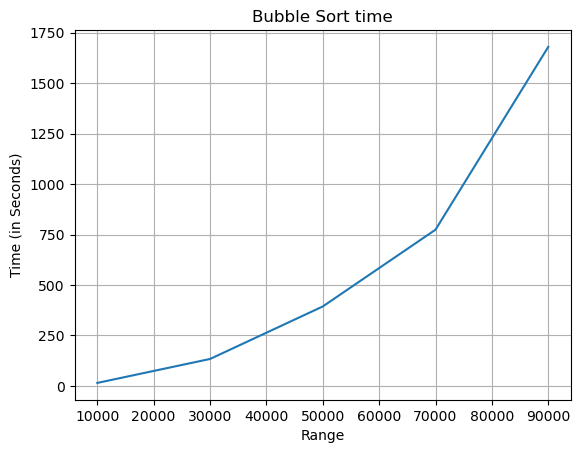

In [5]:
import week5hw as lib
lib.main()

<b>Testing Shell Sort</b>
<br>

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  3


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  -1


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  1


Option 1 selected

Running Shell Sort...
Finished
--- 10000 items sorted in 3.662139 seconds ---

Running Shell Sort...
Finished
--- 30000 items sorted in 33.420996 seconds ---

Running Shell Sort...
Finished
--- 50000 items sorted in 94.187305 seconds ---

Running Shell Sort...
Finished
--- 70000 items sorted in 182.220969 seconds ---

Running Shell Sort...
Finished
--- 90000 items sorted in 305.947794 seconds ---



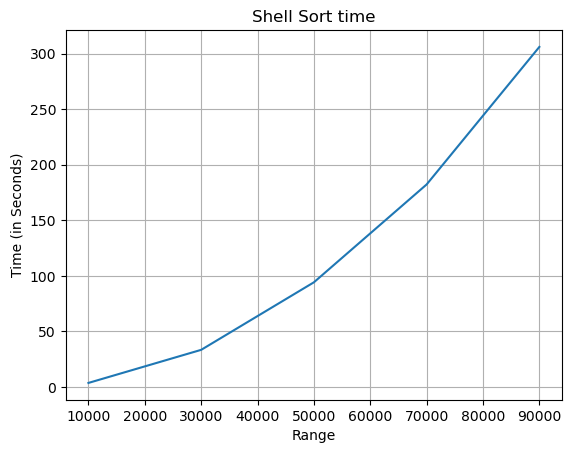

In [4]:
import week5hw as lib
lib.main()

<b>Testing Quick Sort</b>
<br>

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  3


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  -1


Incorrect value entered!  Please try again

Choose a sort algorithm to test:
Enter 0 for Bubble Sort
Enter 1 for Shell Sort
Enter 2 for Quick Sort


Make your selection:  2


Option 2 selected

Running Quick Sort...
Finished
--- 10000 items sorted in 0.017756 seconds ---

Running Quick Sort...
Finished
--- 30000 items sorted in 0.062766 seconds ---

Running Quick Sort...
Finished
--- 50000 items sorted in 0.111349 seconds ---

Running Quick Sort...
Finished
--- 70000 items sorted in 0.166314 seconds ---

Running Quick Sort...
Finished
--- 90000 items sorted in 0.243563 seconds ---



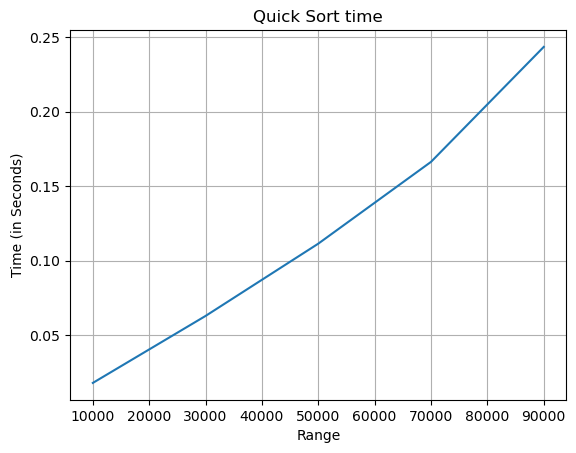

In [3]:
import week5hw as lib
lib.main()